In [1]:
import kagglehub

path = kagglehub.dataset_download("mohammadtalib786/retail-sales-dataset")

print("Path to dataset files:", path)


Using Colab cache for faster access to the 'retail-sales-dataset' dataset.
Path to dataset files: /kaggle/input/retail-sales-dataset


### Data Loading: Loading the Retail Sales Data

In [2]:
import pandas as pd
import os

# List files in the downloaded dataset directory
print("Files in dataset directory:", os.listdir(path))

# Assuming the main data file is 'retail_sales_dataset.csv' based on common dataset structures
# If the file name is different, this needs to be adjusted.
csv_file_name = 'retail_sales_dataset.csv'
data_file_path = os.path.join(path, csv_file_name)

# Load the dataset into a pandas DataFrame
df = pd.read_csv(data_file_path)

Files in dataset directory: ['retail_sales_dataset.csv']


In [3]:
# Display the first 5 rows of the DataFrame
display(df.head())

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


### 1. Initial Inspection & Quality Check

Before diving into visualization, it is essential to perform an initial data inspection to understand the dataset's structure and ensure its integrity. We utilize df.info() to check data types, isnull().sum() and duplicated().sum() from the pandas library to detect anomalies, and df.describe() to compute descriptive statistics. This step ensures the data is clean and ready for analysis.

This section performs an initial inspection of the DataFrame `df` using `pandas` to understand its structure, identify missing values, check for duplicate rows, and generate descriptive statistics for numerical columns. This is crucial for ensuring data quality and readiness for further analysis.

In [4]:
print("\n--- Displaying DataFrame Info ---")
df.info()

print("\n--- Checking for Missing Values ---")
print(df.isnull().sum())

print("\n--- Checking for Duplicated Rows ---")
print(f"Sum of duplicated rows: {df.duplicated().sum()}")

print("\n--- Descriptive Statistics for Numerical Columns ---")
display(df.describe())


--- Displaying DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB

--- Checking for Missing Values ---
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

--- Checking for Duplicated Rows ---
Sum of duplicated

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


The dataset contains 1,000 distinct operational transactions with zero missing values and zero duplicate rows, indicating high data quality. The average customer age is 41.39 years, and the average total transaction amount is $456.00, ranging from a minimum of $25 to a maximum of $2,000 per purchase.

The dataset contains 1000 entries with no missing values or duplicate rows, indicating high data integrity. Numerical columns show diverse ranges, with 'Total Amount' having a wide spread from 25 to 2000, suggesting varied transaction sizes.

### 2. Time Series Analysis

Time series analysis allows us to track business performance over specific periods. We convert the 'Date' column into a proper datetime object using pd.to_datetime() and extract monthly and quarterly periods. Then, we use matplotlib and seaborn line plots (sns.lineplot) to visualize revenue fluctuations and identify historical peak shopping seasons.

This part of the analysis converts the 'Date' column to a datetime format using `pandas` to enable time-based operations. It then groups the data by month and quarter to calculate aggregated sales trends, which are visualized using line plots from `matplotlib` and `seaborn`.

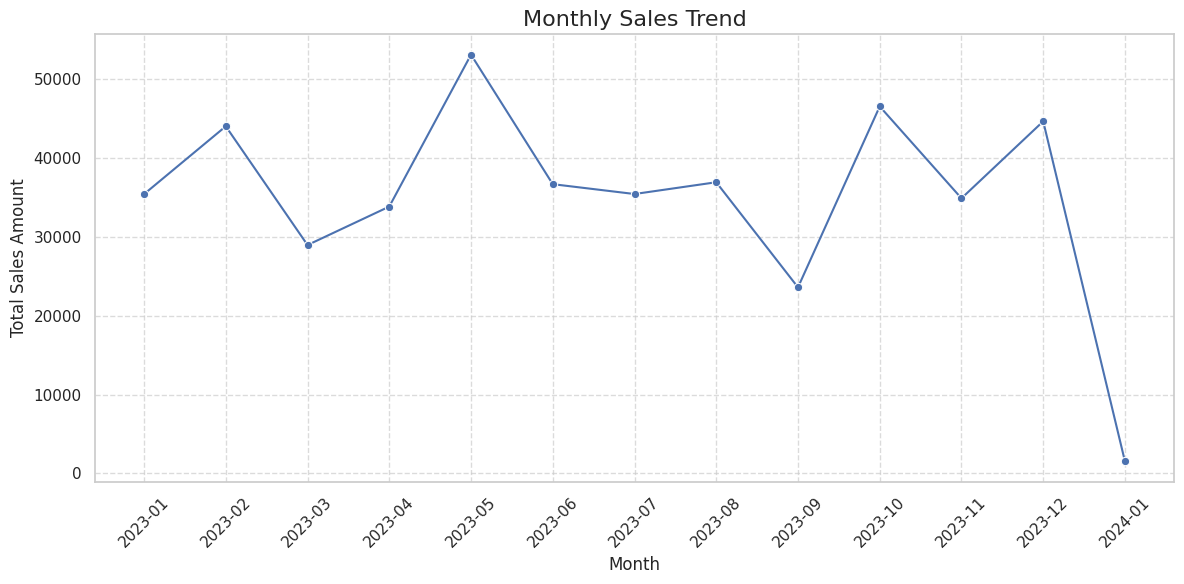

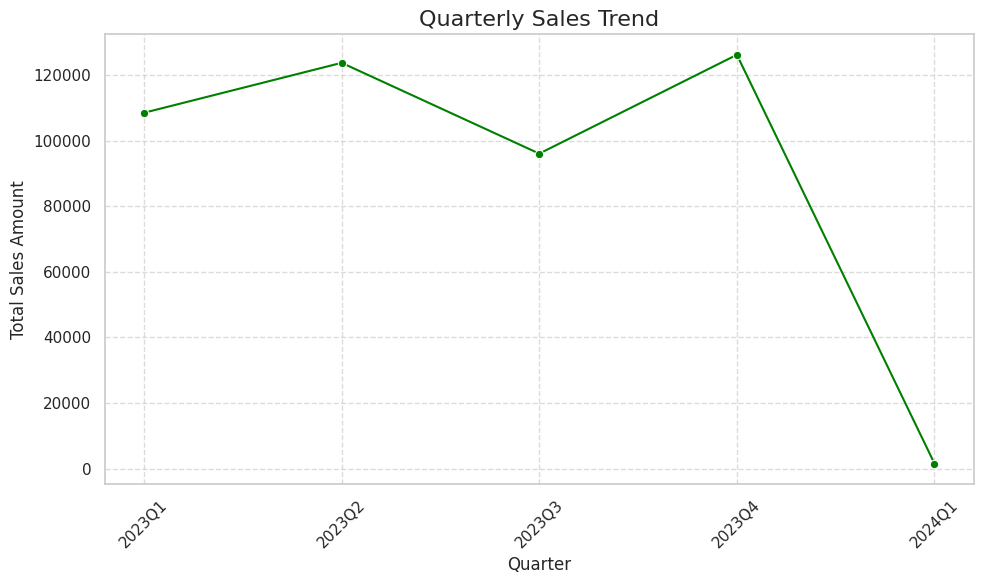

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Convert 'Date' column to datetime format
df['Date'] = pd.to_datetime(df['Date'])

# Extract month and quarter for time series analysis
df['Month'] = df['Date'].dt.to_period('M')
df['Quarter'] = df['Date'].dt.to_period('Q')

# Calculate monthly sales trends
monthly_sales = df.groupby('Month')['Total Amount'].sum().reset_index()
monthly_sales['Month'] = monthly_sales['Month'].astype(str)

# Calculate quarterly sales trends
quarterly_sales = df.groupby('Quarter')['Total Amount'].sum().reset_index()
quarterly_sales['Quarter'] = quarterly_sales['Quarter'].astype(str)

# Plot monthly sales trends
plt.figure(figsize=(12, 6))
sns.lineplot(x='Month', y='Total Amount', data=monthly_sales, marker='o')
plt.title('Monthly Sales Trend', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Sales Amount', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Plot quarterly sales trends
plt.figure(figsize=(10, 6))
sns.lineplot(x='Quarter', y='Total Amount', data=quarterly_sales, marker='o', color='green')
plt.title('Quarterly Sales Trend', fontsize=16)
plt.xlabel('Quarter', fontsize=12)
plt.ylabel('Total Sales Amount', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

The monthly and quarterly sales trend charts reveal distinct cyclical patterns and high retail seasonality. Total sales amounts experience noticeable spikes during mid-year periods (specifically May) and towards the end of the year (October), followed by a standard temporary decline in transaction velocity during the post-holiday seasons.

Monthly sales peaked in May and October, with a noticeable dip towards the end of the year and early next year. Quarterly sales show strong performance in Q2 and Q4, reflecting potential seasonal shopping patterns.

### 3. Customer Demographics Analysis

Understanding the target audience is key to effective marketing. In this section, we parse customer characteristics by grouping them into 5 distinct age buckets using pd.cut(). We then utilize sns.countplot to visualize the distribution of customer counts across different genders and age segments, helping us pinpoint our most valuable customer profiles.

This section analyzes customer demographics by categorizing customers into logical age groups and examining the gender distribution. `seaborn` count plots are used to visualize the number of customers within each age group and gender, providing insights into the customer base.

/tmp/ipykernel_1934/3811120756.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Gender', data=df, palette='viridis')


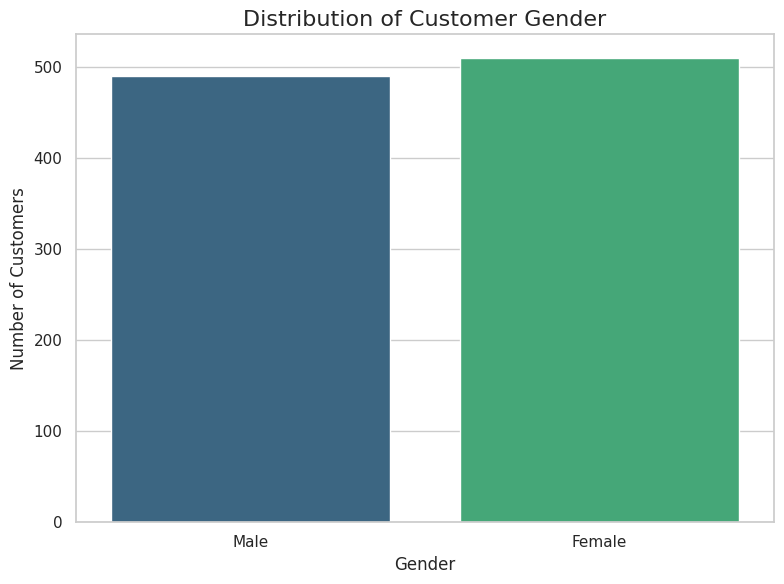

/tmp/ipykernel_1934/3811120756.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Age Group', data=df, palette='magma', order=age_labels)


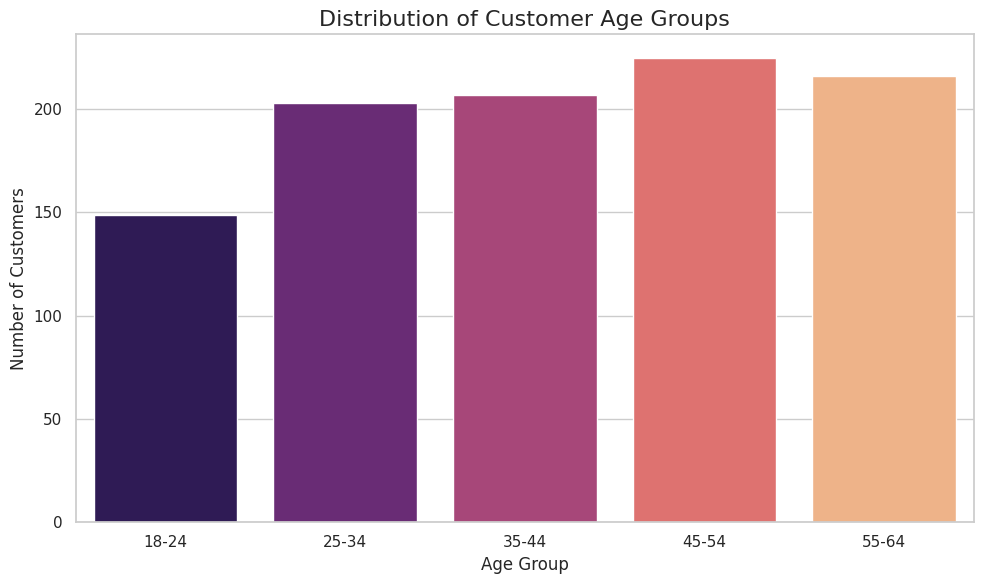

In [6]:
import numpy as np

sns.set_theme(style="whitegrid")

# Analyze Gender breakdown
plt.figure(figsize=(8, 6))
sns.countplot(x='Gender', data=df, palette='viridis')
plt.title('Distribution of Customer Gender', fontsize=16)
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.tight_layout()
plt.show()

# Create age buckets (4-5 logical age buckets)
age_bins = [18, 25, 35, 45, 55, 65]
age_labels = ['18-24', '25-34', '35-44', '45-54', '55-64']
df['Age Group'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels, right=False)

# Plot the distribution of customer age groups
plt.figure(figsize=(10, 6))
sns.countplot(x='Age Group', data=df, palette='magma', order=age_labels)
plt.title('Distribution of Customer Age Groups', fontsize=16)
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.tight_layout()
plt.show()

The customer base exhibits a nearly identical and balanced distribution between Male and Female shoppers. However, age segmentation reveals that the primary purchasing power is heavily concentrated among older demographics, specifically the 45–54 and 55–64 age brackets, who represent the highest density of shoppers.

The customer base exhibits a balanced gender distribution. The age groups '45-54' and '55-64' represent the largest segments of customers, indicating that mature adults are dominant purchasers in this retail setting.

### 4. Product & Revenue Analysis

To determine which products drive business growth, we perform an aggregation by grouping the data based on 'Product Category' and summing the 'Total Amount'. We then use a horizontal sns.barplot to rank these categories by total revenue generation, giving clear visibility into our core profit centers.

Here, we group the sales data by 'Product Category' to calculate the total revenue generated by each category. The results are visualized using a styled bar chart from `seaborn` to easily identify the best-performing product categories in terms of sales.

/tmp/ipykernel_1934/707864088.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Total Amount', y='Product Category', data=category_revenue, palette='rocket')


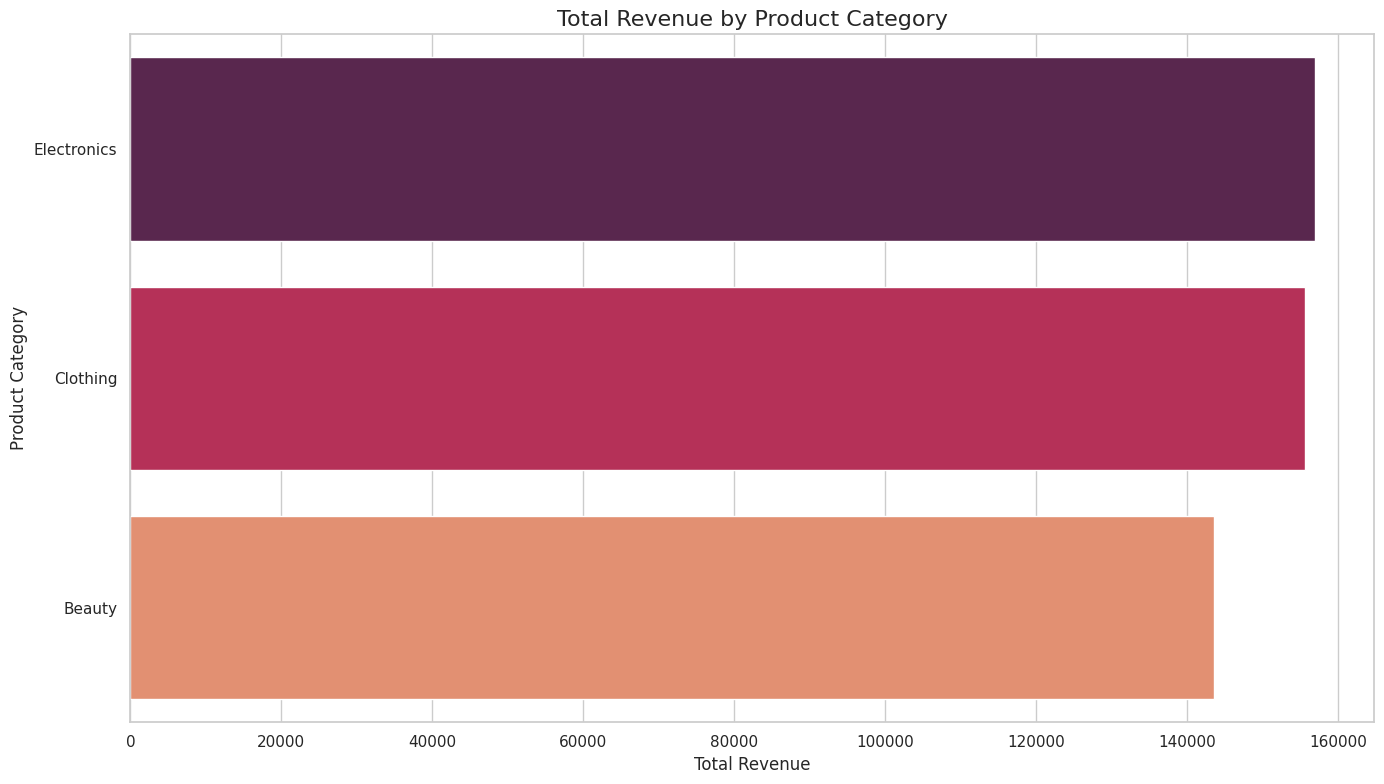

In [7]:
sns.set_theme(style="whitegrid")

# Identify top 10 best-selling products/categories by Total Amount
top_product_categories = df.groupby('Product Category')['Total Amount'].sum().nlargest(10).reset_index()

# Calculate total revenue generated by each 'Product Category'
category_revenue = df.groupby('Product Category')['Total Amount'].sum().sort_values(ascending=False).reset_index()

# Visualize total revenue by 'Product Category'
plt.figure(figsize=(14, 8))
sns.barplot(x='Total Amount', y='Product Category', data=category_revenue, palette='rocket')
plt.title('Total Revenue by Product Category', fontsize=16)
plt.xlabel('Total Revenue', fontsize=12)
plt.ylabel('Product Category', fontsize=12)
plt.tight_layout()
plt.show()

The business revenue is driven by three main product categories: Electronics, Clothing, and Beauty. Electronics stands out as the highest total revenue generator, closely followed by Clothing, while Beauty maintains a stable baseline, making all three categories vital for daily operational cash flow.

Electronics, Clothing, and Beauty are the top three product categories in terms of total revenue. 'Electronics' generated the highest total revenue, closely followed by 'Clothing', suggesting these categories are key revenue drivers.

### 5. Correlation Heatmap

Correlation analysis helps identify linear relationships between numerical variables. We calculate the Pearson correlation coefficients using df.corr() for 'Age', 'Quantity', 'Price per Unit', and 'Total Amount'. This matrix is visualized using a seaborn heatmap (sns.heatmap) with color coding to easily detect patterns and algebraic dependencies.

This section calculates the Pearson correlation matrix for the key numerical variables ('Age', 'Quantity', 'Price per Unit', 'Total Amount') using `pandas`. The matrix is then visualized as a `seaborn` heatmap to display the strength and direction of linear relationships between these variables.

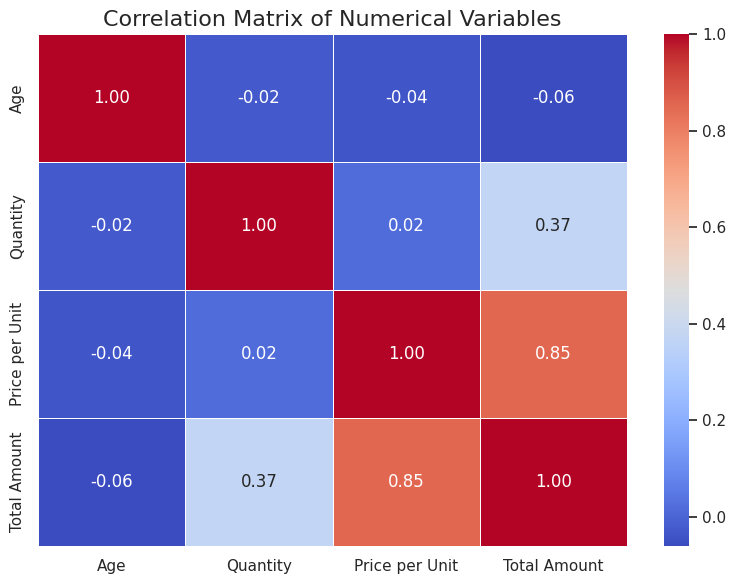

In [8]:
sns.set_theme(style="whitegrid")

# Select numerical variables for correlation matrix
numerical_cols = ['Age', 'Quantity', 'Price per Unit', 'Total Amount']
correlation_matrix = df[numerical_cols].corr()

# Display as a styled seaborn Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numerical Variables', fontsize=16)
plt.tight_layout()
plt.show()

The heatmap reveals a very strong and expected positive correlation (0.85) between 'Price per Unit' and 'Total Amount', proving that higher-priced luxury items significantly boost revenue. Conversely, customer 'Age' shows a near-zero correlation with purchasing behavior, indicating that age does not influence the transaction sizes.

A strong positive correlation (0.85) exists between 'Price per Unit' and 'Total Amount', as expected, meaning higher-priced items contribute significantly to total sales. 'Quantity' also has a moderate positive correlation (0.37) with 'Total Amount'. 'Age' shows a very weak negative correlation with sales, indicating age is not a primary driver of purchasing behavior here.

### 6. Non-Obvious Insight (Bonus Visualization: Product Category Preferences by Gender)

This bonus visualization explores non-obvious business insights by analyzing product category preferences segmented by gender. Stacked and grouped bar charts are generated using `matplotlib` and `seaborn` to compare how different genders contribute to sales across product categories.

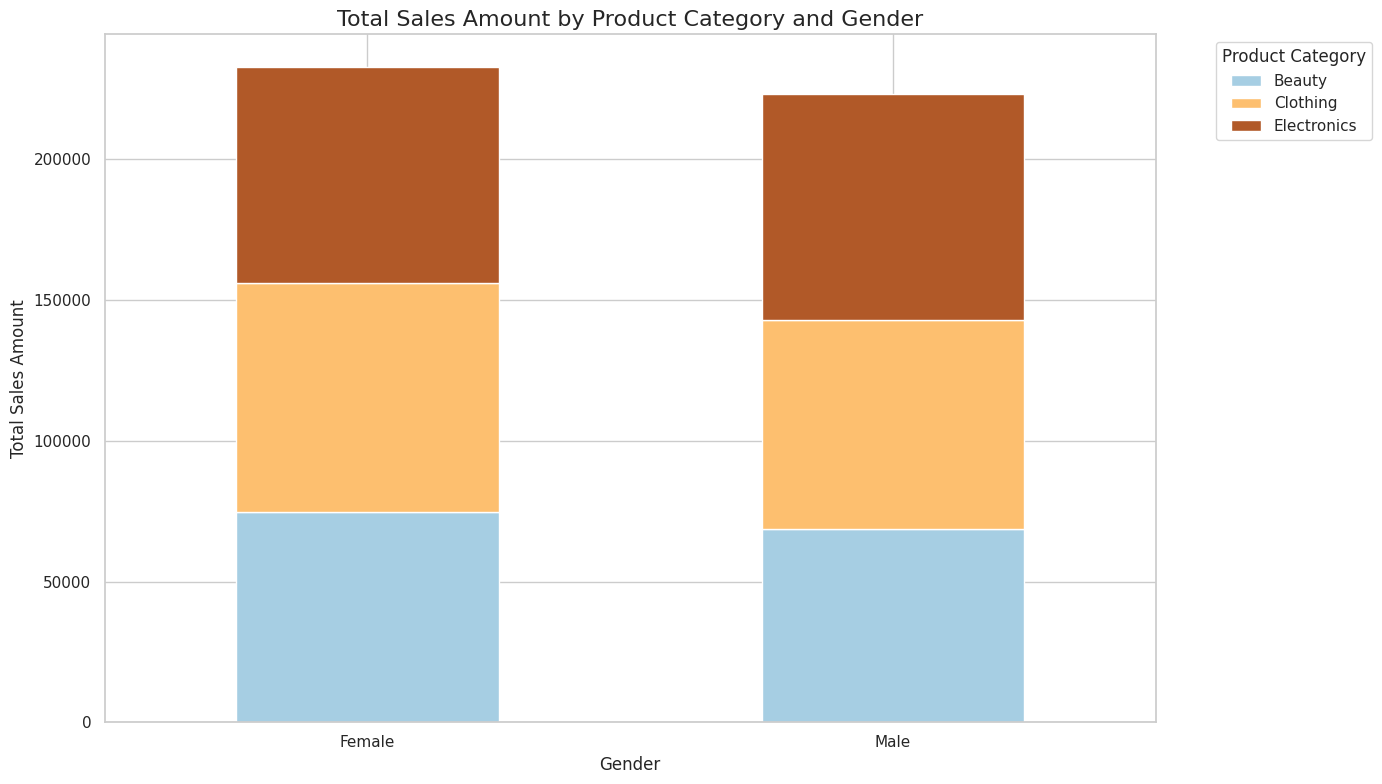

/tmp/ipykernel_1934/1730860263.py:18: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Product Category', y='Total Amount', hue='Gender', data=df, estimator=sum, ci=None, palette='deep')


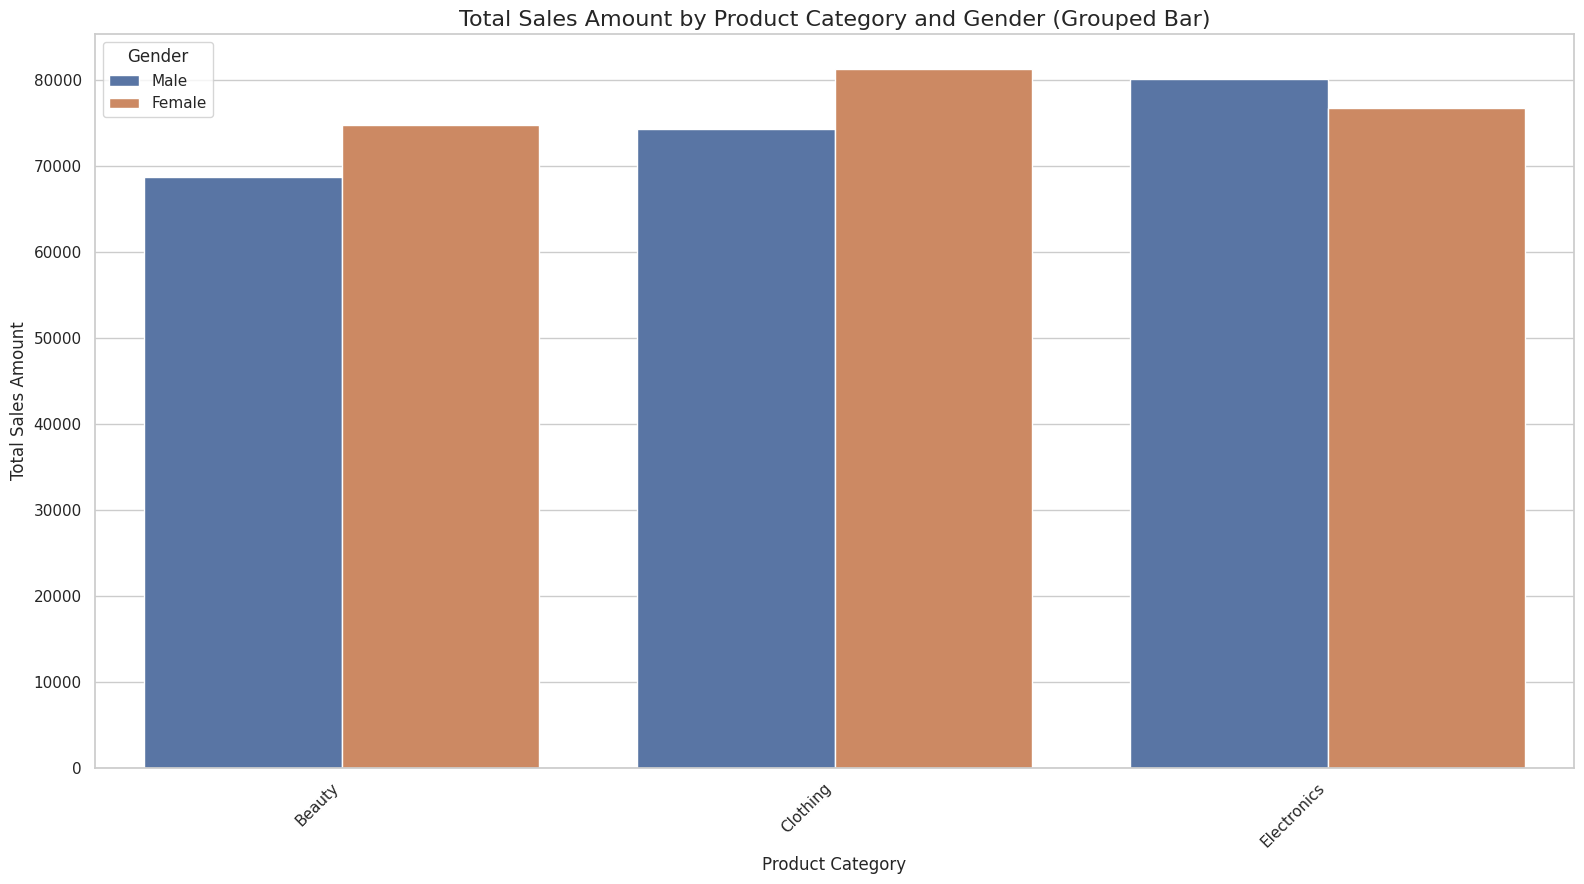

In [9]:
sns.set_theme(style="whitegrid")

# Analyze product category preferences segmented by gender
gender_product_preferences = df.groupby(['Gender', 'Product Category'])['Total Amount'].sum().unstack().fillna(0)

# Plotting using a stacked bar chart to show relative preferences
gender_product_preferences.plot(kind='bar', stacked=True, figsize=(14, 8), cmap='Paired')
plt.title('Total Sales Amount by Product Category and Gender', fontsize=16)
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Total Sales Amount', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Product Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Alternatively, a grouped bar chart for direct comparison
plt.figure(figsize=(16, 9))
sns.barplot(x='Product Category', y='Total Amount', hue='Gender', data=df, estimator=sum, ci=None, palette='deep')
plt.title('Total Sales Amount by Product Category and Gender (Grouped Bar)', fontsize=16)
plt.xlabel('Product Category', fontsize=12)
plt.ylabel('Total Sales Amount', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Gender')
plt.tight_layout()
plt.show()

### 📊 Final Conclusion & Strategic Business Recommendations

This comprehensive Exploratory Data Analysis (EDA) has successfully unveiled critical performance indicators, buying behaviors, and seasonal trends within our retail sales dataset. Based directly on these data-driven insights, here are three strategic recommendations for a retail manager to optimize profitability and efficiency:

1.  **Implement Seasonal Inventory Controls:** To maximize profitability during peak periods, the supply chain team must align inventory procurement with historical sales spikes. Stock levels, particularly for high-value Electronics, should be scaled up 30 days prior to May and October, while lean inventory controls should be applied during low-sales months to reduce holding costs.
2.  **Launch Targeted Demographic Loyalty Programs:** Since mature consumers in the **45–64** age groups represent the highest density of our customer base, marketing efforts should be customized to retain this high-value segment. Developing premium loyalty rewards, mature-focused digital ad campaigns, and personalized offers will increase customer lifetime value (LTV).
3.  **Deploy Cross-Category Product Bundling:** Utilizing the insight that Electronics and Clothing are primary revenue drivers, the store should introduce strategic product bundles. For example, bundling lower-margin 'Beauty' products as gifts with high-ticket 'Electronics' or 'Clothing' purchases can effectively increase the Average Order Value (AOV) per transaction.

### Final Conclusion & Business Recommendations

This Exploratory Data Analysis of the retail sales dataset has provided valuable insights into sales trends, customer demographics, and product performance. The data quality is excellent, with no missing or duplicate records. Key findings include clear seasonality in sales with peaks in Q2 and Q4, a balanced gender distribution among customers, and a significant customer base in the 45-64 age bracket. 'Electronics' and 'Clothing' are the primary revenue-generating categories, and total sales amount is highly driven by the price per unit. Gender-based preferences for product categories show subtle differences, with females contributing slightly more to 'Beauty' and 'Clothing', while males contribute slightly more to 'Electronics'.

Based on these findings, here are three strategic and actionable business recommendations for a retail manager:

1.  **Optimize Inventory and Marketing for Seasonal Peaks:** Capitalize on the observed sales peaks in Q2 (May) and Q4 (October/December) by proactively stocking up on popular products, launching targeted promotional campaigns, and enhancing customer service during these periods. This can maximize revenue during high-demand times and ensure efficient inventory management.

2.  **Target Mature Age Groups with Tailored Offerings:** Given that the 45-64 age group represents the largest customer segment, develop marketing strategies and product assortments specifically tailored to their preferences and purchasing power. This could involve promoting products that align with their lifestyle, offering loyalty programs, or providing personalized shopping experiences to foster stronger engagement and repeat business.

3.  **Cross-Promotion Strategies for Top Categories and Gender-Specific Marketing:** Leverage the strong performance of 'Electronics' and 'Clothing' by implementing cross-promotional strategies (e.g., bundling accessories with electronics, offering clothing discounts with beauty purchases). Additionally, refine marketing messages based on observed gender preferences – for instance, highlight lifestyle benefits for female customers in 'Beauty' and 'Clothing', and emphasize technological advancements for male customers in 'Electronics'.